In [1]:
from typing import Callable
from pathlib import Path

from numpy.typing import NDArray
import numpy as np

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask

import darksun as ds


ds.show.set_figures_darkbkg()

In [2]:
#BASEPATH: str = '...'
BASEPATH: str = '/mnt/d/PhD_AASS/Coding/Images_fits'
MASK_FITS: str = "wfm_mask_NTHT_20260129_CORRECTED.fits"

UPS_X: int = 5
UPS_Y: int = 1
wfm = codedmask(f'{BASEPATH}/{MASK_FITS}', UPS_X, UPS_Y)

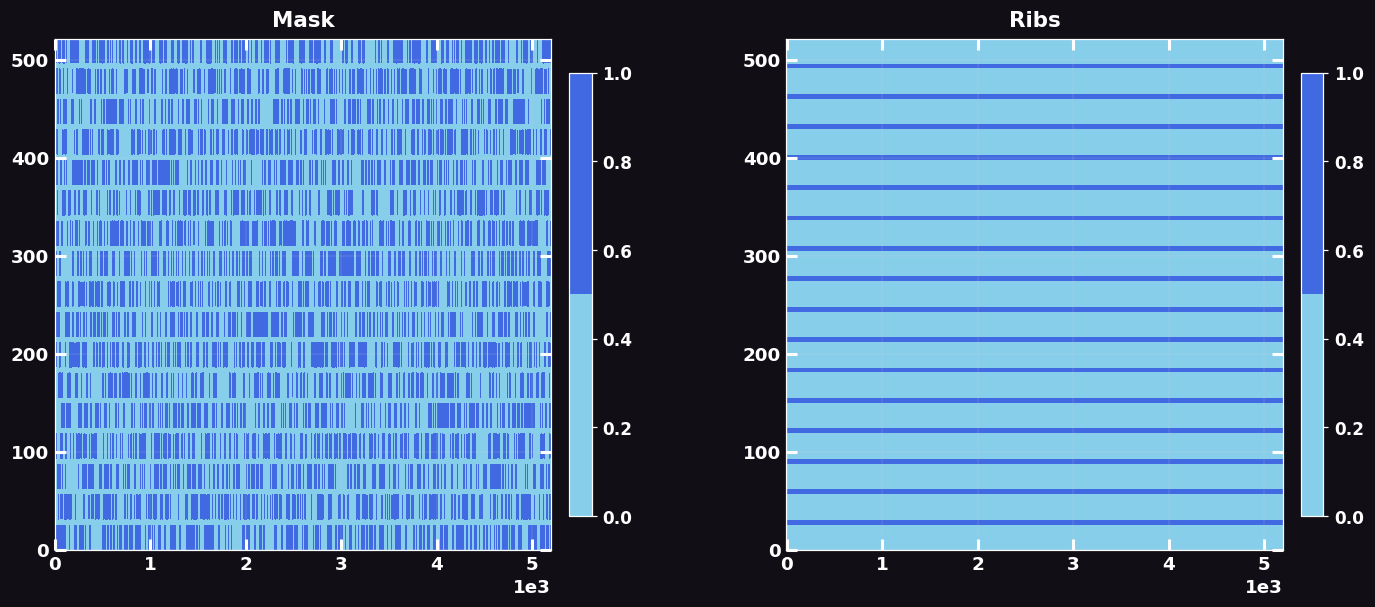

In [3]:
from matplotlib.colors import ListedColormap as lc

def get_ribs(
    camera: CodedMaskCamera,
    ely_dim: float = 13.0,
    n_ely: int = 17,
    ribsy_dim: float = 2.5,
) -> NDArray:
    """Creates a blueprint of the mask ribs."""
    px_dim_y = camera.specs.mask_deltay / camera.upscale_f.y
    n_ely_px = int(ely_dim / px_dim_y)
    n_riby_px = int(ribsy_dim / px_dim_y)
    base = np.zeros_like(camera.mask, dtype=int)
    for idx in range(n_ely):
        base[(idx + 1) * (n_ely_px + n_riby_px) - n_riby_px : (idx + 1) * (n_ely_px + n_riby_px), :] += 1
    return base



ribs: NDArray = get_ribs(wfm)

img_kwargs={
    'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
    'cmap': lc(["SkyBlue", "RoyalBlue"]),
}
dmaps=(
    ds.map4image(
        wfm.mask,
        title='Mask',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        ribs,
        title='Ribs',
        img_kwargs=img_kwargs,
    ),
    #ds.map4image(
    #    wfm.mask + ribs,
    #    title='mask + ribs',
    #    img_kwargs=img_kwargs,
    #),
)
ds.image_plot(
    dmaps=dmaps,
    ncols=len(dmaps),
)


In [4]:
from bloodmoon.images import fshift

def show_arr(
    arr: NDArray | tuple[NDArray, ...],
    title: str | tuple[str, ...],
) -> None:
    """Plots the given 2D array as image."""
    _arr = (arr,) if isinstance(arr, np.ndarray) else arr
    _title = (title,) if isinstance(title, str) else title
    img_kwargs={
    'aspect': _arr[0].shape[1] / _arr[0].shape[0],
    #'cmap': lc(['DeepPink', 'RoyalBlue']),  # lc(["SkyBlue", "Orange"])
    }
    dmaps = tuple(
        ds.map4image(a, title=t, img_kwargs=img_kwargs)
        for a, t in zip(_arr, _title)
    )
    ncols = np.ceil(np.sqrt(len(dmaps)))
    nrows = np.round(np.sqrt(len(dmaps)), 0)
    ds.image_plot(
        dmaps=dmaps,
        ncols=int(ncols),
        nrows=int(nrows),
    )
    return None


arr: NDArray = np.array(
    [
        [0, 0, 0.1, 0.1, 0.1, 0.1, 0, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 0.9, 0.9, 0.9, 0.9, 0, 0, 0, 0, 0.9, 0.9, 0.9, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0.1, 0.1, 0.1, 0.1, 0, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 0.9, 0.9, 0.9, 0.9, 0, 0, 0, 0, 0.9, 0.9, 0.9, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0.1, 0.1, 0.1, 0.1, 0, 0, 0, 0, 0.1, 0.1, 0.1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0],
    ],
    dtype=float,
)
arr = np.flip(arr, axis=0)

In [5]:
arr_mask_pos = (arr > 0) & (fshift(arr, -1, 0) > 0)
pos = arr * arr_mask_pos

arr_mask_diff_y = (arr - fshift(arr, -1, 0)) > 0
pos_diff_y = arr * arr_mask_diff_y

arr_mask_diff_x = (arr > 0) & (fshift(arr, 0, 1) > 0)
pos_diff_x = pos_diff_y * arr_mask_diff_x

cutted_mask = (arr - pos_diff_x) > 0
cutted = arr * cutted_mask

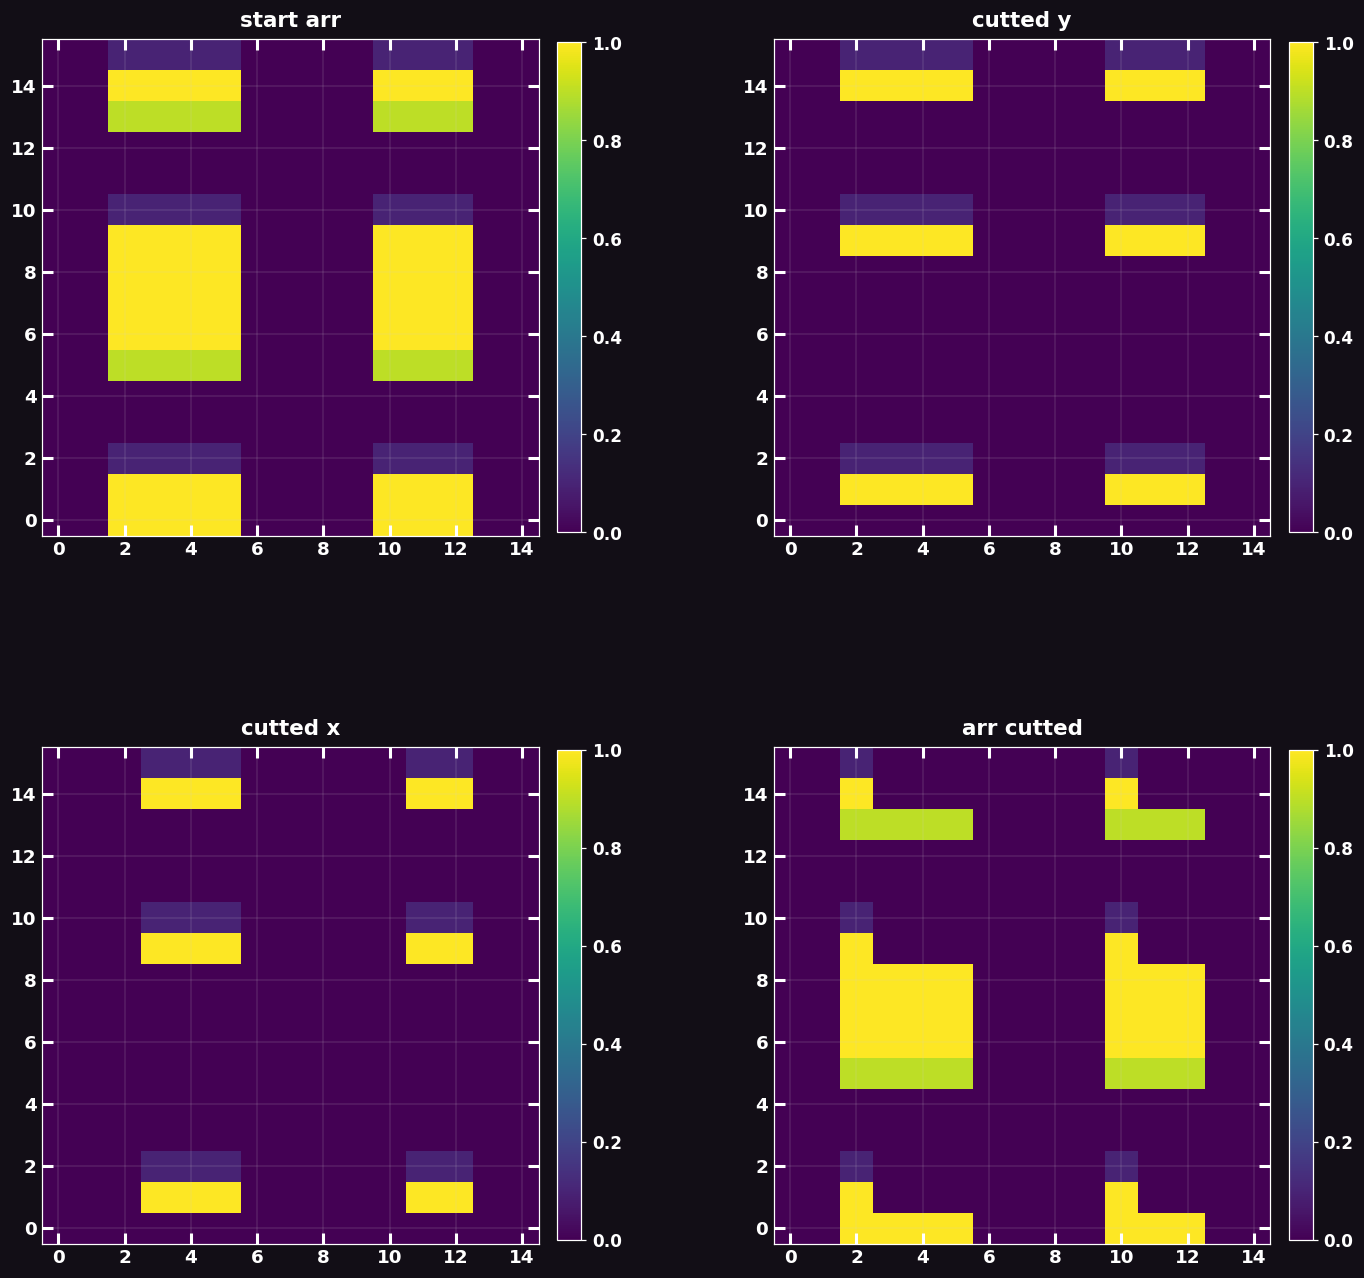

In [6]:
arrs = (
    arr, pos_diff_y, pos_diff_x, cutted,
)
titles = (
    'start arr', 'cutted y', 'cutted x', 'arr cutted',
)
show_arr(arrs, titles)

In [7]:
from dataclasses import dataclass

@dataclass
class RibsStructure:
    """
    Container for camera mask ribs structure specifics in [mm].
    """
    ribs_dim: float
    supp_heigth: float
    supp_equiv_thickness: float

def get_ribs_struct(
    ribs_dim: float = 2.5,
    supp_heigth: float = 1.75,
    supp_equiv_thickness: float = 0.25,
) -> RibsStructure:
    ribs = RibsStructure(
        ribs_dim=ribs_dim,
        supp_heigth=supp_heigth,
        supp_equiv_thickness=supp_equiv_thickness,
    )
    return ribs

In [8]:
from bloodmoon.coords import shift2angle
from bloodmoon.images import _erosion
from bloodmoon.optim import apply_vignetting as std_vignetting


#def project_ribs_support(dist: float) -> float:
#    """
#    Projects the mask ribs support on the mask binning elements, and
#    corrects the projection value to allows for correct erosion
#    of the mask physical elements starting from the pixels' edges.
#    """
#    shift_px = shift_y / px_dim_y
#    bin_erosion_start = (1.0 - abs(shift_px - int(shift_px))) * px_dim_y
#    return dist + np.sign(dist) * bin_erosion_start

#dist_y = correct_proj_eroded_dist(erosion_dist_y)

#f'Pixel corrected erosion from ribs: {dist_y / px_dim_y}\n'


def apply_vignetting(
    camera: CodedMaskCamera,
    shadowgram: NDArray,
    shift_x: float,
    shift_y: float,
    ribs_struct: RibsStructure,
) -> NDArray:
    """
    Apply vignetting effects to a shadowgram based on source position.
    """
    px_dim_y = camera.specs.mask_deltay / camera.upscale_f.y

    def project_ribs_support(dist: float) -> float:
        """
        Projects the mask ribs support on the mask binning elements, and
        corrects the projection value to allows for correct erosion
        of the mask physical elements starting from the pixels' edges.
        """
        shift_px = shift_y / px_dim_y
        bin_erosion_start = (
            abs(shift_px - int(shift_px)) if (shift_px > 0)
            else abs(shift_px - int(shift_px)) - 1.0
        )
        return dist + bin_erosion_start * px_dim_y

    def apply_ribs_vignetting(sg: NDArray, step: float, cut: float) -> NDArray:
        """Applies camera mask ribs structure correction for vignetting."""
        eroded = _erosion(sg.T, step, cut)
        return eroded.T

    # apply vignetting for standard mask structure
    sg_vignetted = std_vignetting(camera, shadowgram, shift_x, shift_y)

    # correct vignetted sg for the ribs structure
    # - compute critical angle for correction activation
    #
    #                    \ 
    #                  <-->  
    #                  _t__\     
    #                 |   | \  crit_angle
    #                 |   |__\
    #              h  |   |   \      |      p = 0.5 * (L - t) 
    #                 |   |    \     |      crit_angle = atan(p / h)
    #                 |   |     \    |
    #                 |   |      \   |
    #         --------------------\__|
    #         <------------------> \ |  crit_angle
    #                    p <----->  \|    
    #                                |
    #
    struct_eff_base = 0.5 * (ribs_struct.ribs_dim - ribs_struct.supp_equiv_thickness)
    crit_angle_y = abs(np.rad2deg(np.atan(struct_eff_base / ribs_struct.supp_heigth)))
    angle_y = shift2angle(camera, shift_y)
    # - compute ribs structure effect
    if (abs(angle_y) > crit_angle_y):
        erosion_dist_y = ribs_struct.supp_heigth * np.tan(np.deg2rad(abs(angle_y))) - struct_eff_base
        # since the ribs correction is applied before the mask close elements,
        # the shift of the array must be anti-parallel, and we apply a minus
        erosion_dist_y *= (-np.sign(angle_y))
        dist_y = project_ribs_support(erosion_dist_y)
        sg_corrected = apply_ribs_vignetting(sg_vignetted, px_dim_y, dist_y)
        print(
            f'Pixel erosion from ribs: {erosion_dist_y / px_dim_y}\n'
            f'Pixel corrected erosion from ribs: {dist_y / px_dim_y}\n'
        )
    else:
        sg_corrected = sg_vignetted

    return sg_corrected

Pixel erosion from ribs: -1.2499999999999996
Pixel corrected erosion from ribs: -1.1500000000000337

Same sg: False



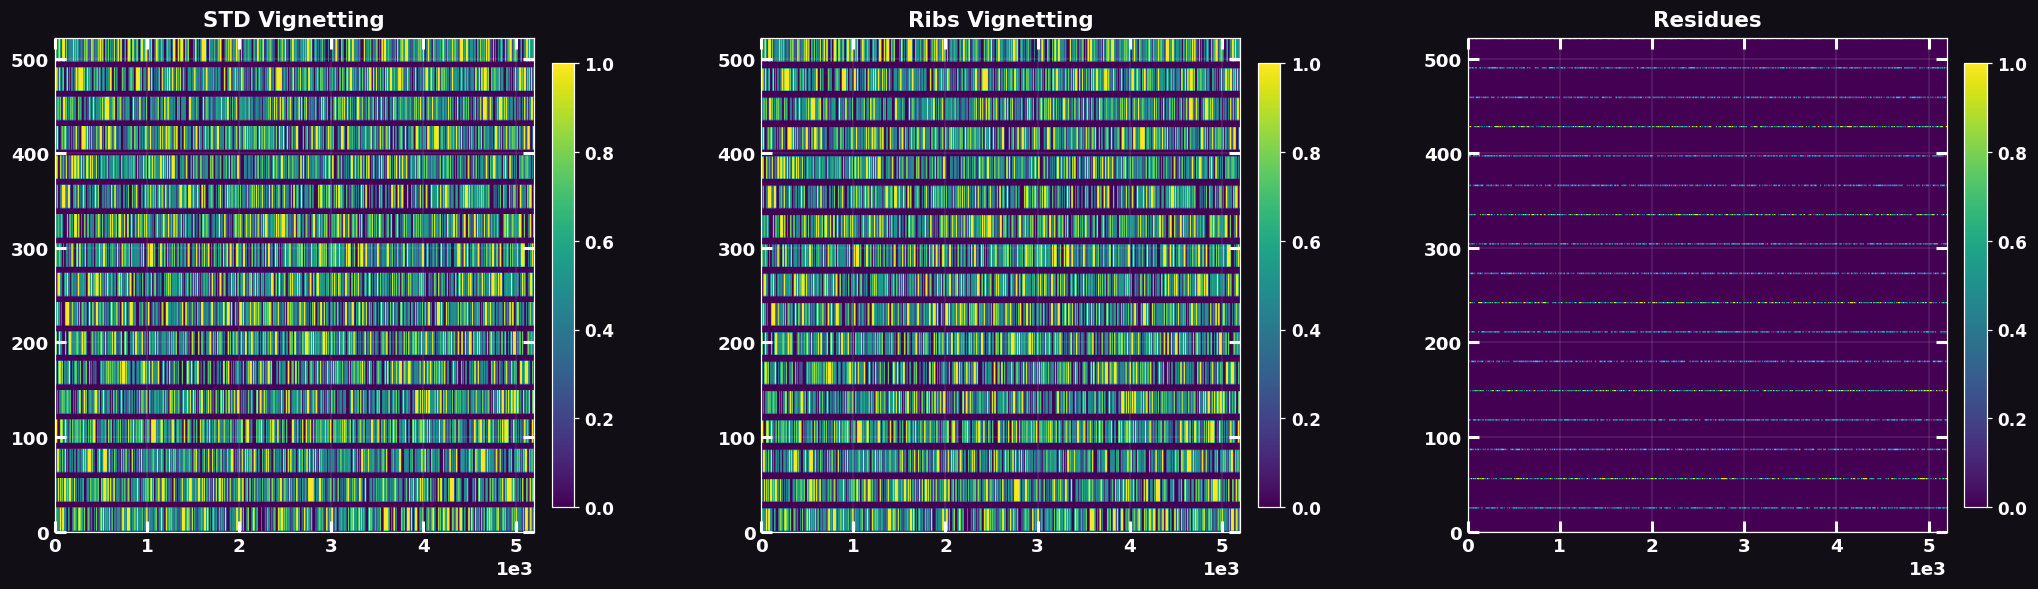

In [9]:
from bloodmoon.coords import angle2shift

angle_x, angle_y = 0.0, 45


sx, sy = map(lambda x: angle2shift(wfm, x), (angle_x, angle_y))
std_vignetted = std_vignetting(wfm, wfm.mask, sx, sy)
ribs_vignetted = apply_vignetting(wfm, wfm.mask, sx, sy, get_ribs_struct())


img_kwargs={
    'aspect': wfm.shape_detector[1] / wfm.shape_detector[0],
}
dmaps=(
    ds.map4image(
        std_vignetted,
        title='STD Vignetting',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        ribs_vignetted,
        title='Ribs Vignetting',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        std_vignetted - ribs_vignetted,
        title='Residues',
        img_kwargs=img_kwargs,
    ),
)

print(
    f'Same sg: {np.allclose(std_vignetted, ribs_vignetted)}\n'
)

ds.image_plot(
    dmaps=dmaps,
    ncols=len(dmaps),
)

In [10]:
np.unique(std_vignetted)

array([0. , 0.8, 1. ])

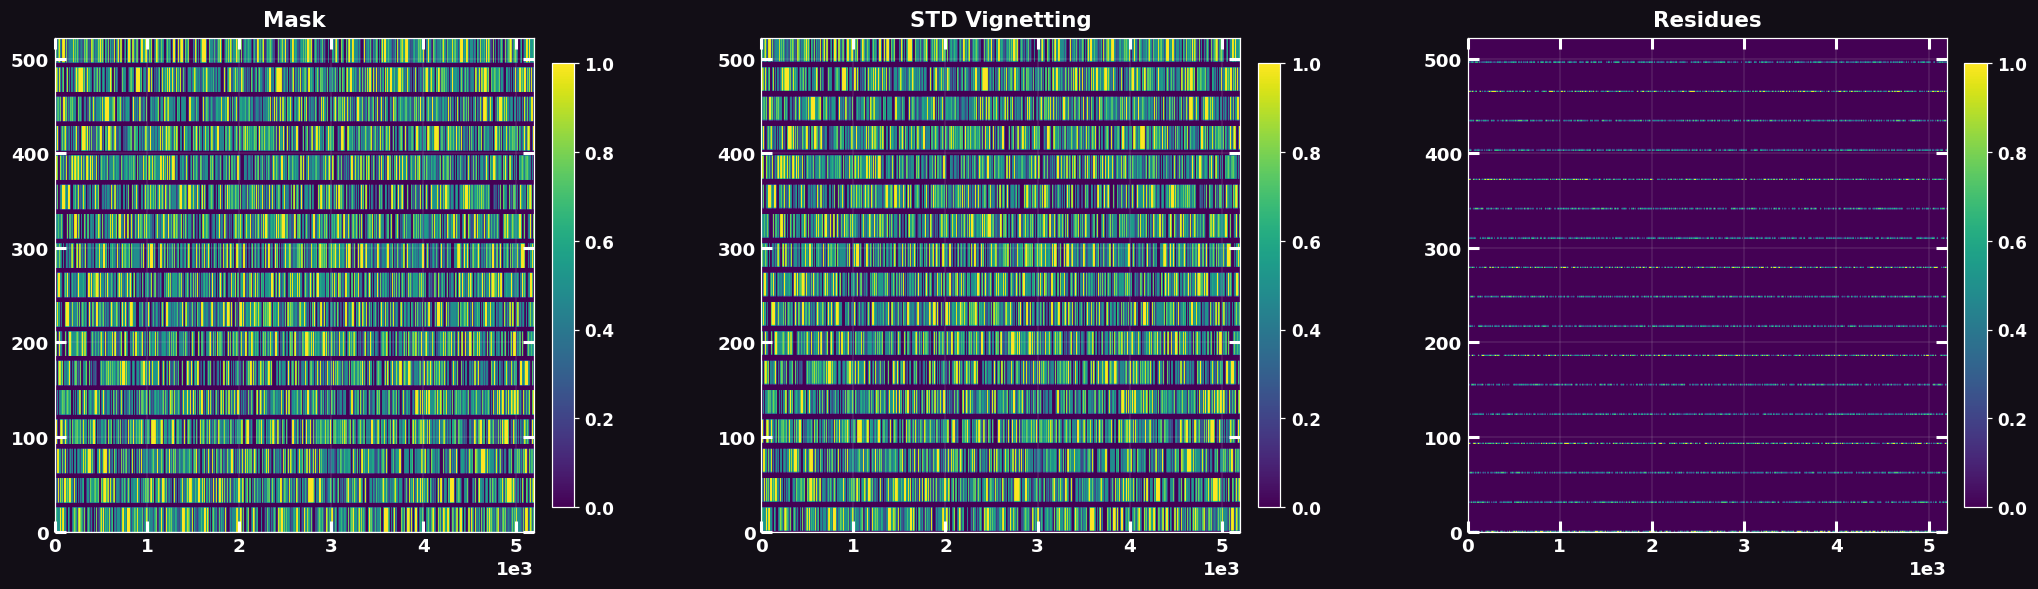

In [11]:
dmaps=(
    ds.map4image(
        wfm.mask,
        title='Mask',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        std_vignetted,
        title='STD Vignetting',
        img_kwargs=img_kwargs,
    ),
    ds.map4image(
        wfm.mask - std_vignetted,
        title='Residues',
        img_kwargs=img_kwargs,
    ),
)

ds.image_plot(
    dmaps=dmaps,
    ncols=len(dmaps),
)

In [12]:
from bloodmoon.images import fshift, _erosion

arr = np.array(
    [
        [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0],
    ]
)

In [106]:
shift_px_x = 0.3
shifted = fshift(arr, 0, shift_px_x)

arr, shifted

(array([[0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0.]]),
 array([[0. , 0. , 0.7, 1. , 1. , 0.3, 0. , 0. , 0.7, 1. , 1. , 0.3, 0. ],
        [0. , 0. , 0.7, 1. , 1. , 0.3, 0. , 0. , 0.7, 1. , 1. , 0.3, 0. ],
        [0. , 0. , 0.7, 1. , 1. , 0.3, 0. , 0. , 0.7, 1. , 1. , 0.3, 0. ]]))

In [110]:
BIN_DIM = 1.0

def correct_cut_px(cut_px: float, shift_px: float) -> float:
    """Corrects cut to account for bin edge start-point erosion."""
    return cut_px + np.sign(cut_px) * (1.0 - abs(shift_px - int(shift_px)))

cut_px = -0.4
cut_corrected_px = correct_cut_px(cut_px, shift_px_x)
eroded = _erosion(shifted, BIN_DIM, cut_corrected_px * BIN_DIM)

shifted, eroded

(array([[0. , 0. , 0.7, 1. , 1. , 0.3, 0. , 0. , 0.7, 1. , 1. , 0.3, 0. ],
        [0. , 0. , 0.7, 1. , 1. , 0.3, 0. , 0. , 0.7, 1. , 1. , 0.3, 0. ],
        [0. , 0. , 0.7, 1. , 1. , 0.3, 0. , 0. , 0.7, 1. , 1. , 0.3, 0. ]]),
 array([[0. , 0. , 0.7, 1. , 0.9, 0. , 0. , 0. , 0.7, 1. , 0.9, 0. , 0. ],
        [0. , 0. , 0.7, 1. , 0.9, 0. , 0. , 0. , 0.7, 1. , 0.9, 0. , 0. ],
        [0. , 0. , 0.7, 1. , 0.9, 0. , 0. , 0. , 0.7, 1. , 0.9, 0. , 0. ]]))

In [111]:
def fract_erosion_corr(cut_px: float, shift_px: float) -> float:
    f = abs(shift_px - int(shift_px))
    cut = abs(cut_px - int(cut_px))
    return 1.0 - (1.0 - f - cut) / (1 - f)


ribs_cut_px = 0.2


ribs_cut_corrct_px = fract_erosion_corr(ribs_cut_px, shift_px_x)
ribs_eroded = _erosion(eroded, BIN_DIM, ribs_cut_corrct_px * BIN_DIM)

eroded, ribs_eroded

(array([[0. , 0. , 0.7, 1. , 0.9, 0. , 0. , 0. , 0.7, 1. , 0.9, 0. , 0. ],
        [0. , 0. , 0.7, 1. , 0.9, 0. , 0. , 0. , 0.7, 1. , 0.9, 0. , 0. ],
        [0. , 0. , 0.7, 1. , 0.9, 0. , 0. , 0. , 0.7, 1. , 0.9, 0. , 0. ]]),
 array([[0. , 0. , 0.5, 1. , 0.9, 0. , 0. , 0. , 0.5, 1. , 0.9, 0. , 0. ],
        [0. , 0. , 0.5, 1. , 0.9, 0. , 0. , 0. , 0.5, 1. , 0.9, 0. , 0. ],
        [0. , 0. , 0.5, 1. , 0.9, 0. , 0. , 0. , 0.5, 1. , 0.9, 0. , 0. ]]))

In [16]:
def project_mask_thickness(shift: float, bin_dim: float) -> float:
    """
    Projects the mask thickness on the mask binning elements, and
    corrects the projection value to allows for correct erosion
    of the mask physical elements starting from the pixels' edges.
    """
    # since the mask detector distance is defined as the distance between the
    # detector top and the mask top, erosion shall cut on the left-side of the
    # shadowgram when sources have negative `angle`.
    # if the mask detector distance was defined as the distance between the
    # detector top and the mask bottom, erosion should have been applied to the
    # right side, i.e. `proj` should be multiplied by -1.
    angle = np.arctan(shift / camera.specs.mask_detector_distance)
    proj = camera.specs.mask_thickness * np.tan(angle)
    shift_px = shift / bin_dim
    # the mask thickness projection has to be corrected by considering the
    # erosion pixel start point, due to the discretisation of the projection
    # https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/new_erosion_20251024.ipynb
    # if the erosion is positive, it has to start from the left bin edge;
    # if negative, it has to start from the right edge of the bin
    bin_erosion_start = (
        abs(shift_px - int(shift_px)) if (shift_px > 0)
        else abs(shift_px - int(shift_px)) - 1.0
    )
    return proj + bin_erosion_start * bin_dim

In [1]:
import numpy as np
from bloodmoon.images import fshift, _erosion

arr = np.array(
    [
        [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0],
    ]
)

In [10]:
BIN_DIM = 1.0

shift_px_x = 0.4
shifted = fshift(arr, 0, shift_px_x)

arr, shifted

(array([[0., 0., 1., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 0., 0.]]),
 array([[0. , 0. , 0.6, 1. , 1. , 0.4, 0. ],
        [0. , 0. , 0.6, 1. , 1. , 0.4, 0. ],
        [0. , 0. , 0.6, 1. , 1. , 0.4, 0. ]]))

In [17]:
#def correct_erosion_value(cut_px: float, shift_px: float) -> float:
#    """Corrects cut to account for bin edge start-point erosion."""
#    fract_cut = abs(cut_px - int(cut_px))
#    fract_shift = abs(shift_px - int(shift_px))
#
#    if (shift_px > 0) != (cut_px > 0):
#        val_px = fract_shift
#    else:
#        val_px = 1.0 - fract_shift
#    
#    if not int(cut_px):
#        if fract_cut <= val_px:
#            corr = (1.0 - val_px) * fract_cut / val_px
#        else:
#            corr = 1.0 - val_px
#    
#    else:
#        if fract_cut <= fract_shift:
#            if fract_cut <= val_px:
#                corr = 1.0 - val_px
#            else:
#                if np.sign(shift_px) == np.sign(cut_px):
#                    if fract_cut <= val_px:
#                        corr = (1.0 - val_px) * fract_cut / val_px
#                    else:
#                        corr = 1.0 - val_px
#                else:
#                    if fract_cut <= val_px:
#                        corr = 1.0 - val_px
#                    else:
#                        corr = (1.0 - val_px) * fract_cut / val_px
#        else:
#            if fract_cut <= val_px:
#                corr = (1.0 - val_px) * fract_cut / val_px
#            else:
#                corr = 1.0 - val_px
#
#    return cut_px + np.sign(cut_px) * corr


def correct_erosion_value(cut_px: float, shift_px: float) -> float:
    """
    Corrects cut to account for bin edge start-point erosion.\n
    When performing the mask erosion during the projection on the detector
    due to the finite mask thickness (or other structures on the camera),
    we have to account for the mask array pixels value, since the erosion
    mechanism is `px_value * (1 - erosion)`.\n
    If the mask pattern array is fshifted, the pixels at the edge of the
    mask physical elements assume values linked to `f_shift`, and have
    to be accounted for when applying the erosion.
    """
    fract_cut = abs(cut_px) % 1  
    fract_shift = abs(shift_px) % 1

    # if no fshift of the mask pattern array, no need for correction
    if not fract_shift:
        return cut_px
    
    # compute effective pixel val after mask is fshifted
    # if the erosion is concordant wrt the mask shifting, then the pixel
    # value is `1.0 - f_shift`, otherwise is just `f_shift`
    concordant = (shift_px > 0) == (cut_px > 0)
    val_px = 1.0 - fract_shift if concordant else fract_shift

    # base condition for using linear scaling vs capping px val
    use_linear = (fract_cut <= val_px)
    # define capping value and direct erosion value
    cap = 1.0 - val_px
    direct = cap * fract_cut / val_px    
    
    # handle decimal erosion
    if not int(cut_px):
        corr = direct if use_linear else cap
    # handle px overstepping erosion
    else:
        if fract_cut <= fract_shift:
            if use_linear:
                corr = cap
            else:
                if concordant:
                    corr = direct if use_linear else cap
                else:
                    corr = cap if use_linear else direct
        else:
            corr = direct if use_linear else cap

    return cut_px + np.sign(cut_px) * corr


cut_px = -1.3

cut_corrected_px = correct_erosion_value(cut_px, shift_px_x)
eroded = _erosion(shifted, BIN_DIM, cut_corrected_px * BIN_DIM)

shifted, eroded

(array([[0. , 0. , 0.6, 1. , 1. , 0.4, 0. ],
        [0. , 0. , 0.6, 1. , 1. , 0.4, 0. ],
        [0. , 0. , 0.6, 1. , 1. , 0.4, 0. ]]),
 array([[0. , 0. , 0.6, 1. , 0.1, 0. , 0. ],
        [0. , 0. , 0.6, 1. , 0.1, 0. , 0. ],
        [0. , 0. , 0.6, 1. , 0.1, 0. , 0. ]]))

In [1]:
import numpy as np

def correct_erosion_value(cut_px: float, shift_px: float) -> float:
    """
    Corrects cut to account for bin edge start-point erosion.\n
    When performing the mask erosion during the projection on the detector
    due to the finite mask thickness (or other structures on the camera),
    we have to account for the mask array pixels value, since the erosion
    mechanism is `px_value * (1 - erosion)`.\n
    If the mask pattern array is fshifted, the pixels at the edge of the
    mask physical elements assume values linked to `f_shift`, and have
    to be accounted for when applying the erosion.
    """
    f_cut = abs(cut_px) % 1  
    f_shift = abs(shift_px) % 1

    # if no fshift of the mask pattern array, no need for correction
    if not f_shift:
        return cut_px
    
    # compute effective pixel val after mask is fshifted
    # if the erosion is concordant wrt the mask shifting, then the pixel
    # value is `1.0 - f_shift`, otherwise is just `f_shift`
    concordant = (shift_px > 0) == (cut_px > 0)
    val_px = 1.0 - f_shift if concordant else f_shift

    # base condition for using linear scaling vs capping px val
    use_linear = f_cut <= val_px
    # define linear and capping erosion correction
    cap = 1.0 - val_px
    linear = cap * f_cut / val_px

    # std erosion value correction
    corr = linear if use_linear else cap

    # handle px overstepping cases 
    if int(cut_px) and (f_cut <= f_shift):
        if not concordant:
            corr = cap if use_linear else linear
        elif use_linear:
            corr = cap

    return cut_px + np.sign(cut_px) * corr

In [2]:
from bloodmoon.images import fshift, _erosion

arr = np.array(
    [
        [0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0],
    ]
)

BIN_DIM = 1.0

shift_px_x = -0.4
shifted = fshift(arr, 0, shift_px_x)

arr, shifted

(array([[0., 0., 1., 1., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 1., 0., 0.],
        [0., 0., 1., 1., 1., 1., 0., 0.]]),
 array([[0. , 0.4, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.4, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.4, 1. , 1. , 1. , 0.6, 0. , 0. ]]))

In [3]:
cut_px = 0.2

cut_corrected_px = correct_erosion_value(cut_px, shift_px_x)
eroded = _erosion(shifted, BIN_DIM, cut_corrected_px * BIN_DIM)

shifted, eroded

(array([[0. , 0.4, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.4, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.4, 1. , 1. , 1. , 0.6, 0. , 0. ]]),
 array([[0. , 0.2, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.2, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.2, 1. , 1. , 1. , 0.6, 0. , 0. ]]))

In [40]:
ribs_cut_px = -1.7

f_s = abs(shift_px_x % 1.0)
shift_val = (f_s if (shift_px_x < 0) else 1 - f_s) + cut_px
#shift_val = _shift_val if (shift_px_x > 0) == (ribs_cut_px > 0) else 1 - f_s
cut_corrected_px = correct_erosion_value(ribs_cut_px, 0.6)
ribs_eroded = _erosion(eroded, BIN_DIM, cut_corrected_px * BIN_DIM)

eroded, ribs_eroded

(array([[0. , 0.2, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.2, 1. , 1. , 1. , 0.6, 0. , 0. ],
        [0. , 0.2, 1. , 1. , 1. , 0.6, 0. , 0. ]]),
 array([[0. , 0.2, 1. , 0.9, 0. , 0. , 0. , 0. ],
        [0. , 0.2, 1. , 0.9, 0. , 0. , 0. , 0. ],
        [0. , 0.2, 1. , 0.9, 0. , 0. , 0. , 0. ]]))